# Attention-weighted object patch tokens for synthetic 80 m Procrustes

The earlier experiment represented each 640×640 object-centred image using DINOv2’s global CLS feature. That feature can be dominated by water, wakes, nearby objects, and other background context when the target becomes small at synthetic 80 m.

This experiment replaces the CLS representation with **attention-weighted object patch tokens**:

1. transform the ground-truth object box into DINOv2’s 224×224 processed image;
2. calculate its fractional overlap with each 14×14 patch token;
3. average CLS-to-patch attention over all heads in the final four transformer layers;
4. multiply attention by object-box coverage;
5. normalize the weights and pool only object-overlapping patch tokens;
6. L2-normalize the resulting 384-dimensional feature.

The experiment then trains a new fixed 30 m linear probe using this representation and repeats validation-selected subspace Orthogonal Procrustes for geometry-only and calibrated synthetic 80 m images.

## What “strip the background” means here

```text
640×640 object-centred image
        ↓ DINOv2 preprocessing: resize to 256, centre-crop to 224
16×16 grid of patch tokens
        ↓ zero weight outside transformed ground-truth box
        ↓ weight remaining tokens by CLS attention
object-focused 384-dimensional feature
```

This removes background tokens from the final pooling operation. It cannot remove context that transformer self-attention has already mixed into an object token, and very small objects may occupy only one patch. It is therefore an object-focused representation rather than a perfectly context-free representation.

Because the method uses ground-truth boxes, it remains an object-classification experiment. A real detector would first need to provide candidate boxes.

In [1]:
from pathlib import Path
import json
import os
import random
import warnings
from dataclasses import dataclass


def find_repo_root(start=Path.cwd()):
    current=Path(start).resolve()
    for candidate in (current,*current.parents):
        if (candidate/".git").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the repository.")

REPO_ROOT=find_repo_root()
os.environ.setdefault("MPLCONFIGDIR",str(REPO_ROOT/".cache"/"matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True,exist_ok=True)
warnings.filterwarnings("ignore",message="IProgress not found.*")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,balanced_accuracy_score,confusion_matrix,f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader,Dataset
from tqdm import tqdm
from transformers import AutoImageProcessor,AutoModel

SEED=42
MODEL_NAME="facebook/dinov2-small"
CANVAS_SIDE=640
CANVAS_FILL=(114,114,114)
BATCH_SIZE=16
NUM_WORKERS=0
LAST_ATTENTION_LAYERS=4
CANDIDATE_DIMENSIONS=[4,8,16,24,32,48,64,96,128,192,256,320,384]

SOURCE_MANIFEST=REPO_ROOT/"data/splits/seadronessee/seadronessee_25_35m_object_split.csv"
SYNTHETIC_MANIFEST=REPO_ROOT/"data/synthetic/seadronessee_30m_to_80m/manifests/paired_manifest.csv"
BASELINE_PROBE=REPO_ROOT/"results/seadronessee_30m/linear_probe_30m.joblib"
FEATURE_ROOT=REPO_ROOT/"data/features/seadronessee/dinov2_small_attention_object_tokens"
RESULT_ROOT=REPO_ROOT/"results/seadronessee_attention_object_tokens"
FEATURE_ROOT.mkdir(parents=True,exist_ok=True)
RESULT_ROOT.mkdir(parents=True,exist_ok=True)

random.seed(SEED); np.random.seed(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",DEVICE)
print("Feature cache:",FEATURE_ROOT)
print("Results:",RESULT_ROOT)

Device: cpu
Feature cache: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\data\features\seadronessee\dinov2_small_attention_object_tokens
Results: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens


## 1. Load manifests and the class definition

In [2]:
objects=pd.read_csv(SOURCE_MANIFEST)
pairs=pd.read_csv(SYNTHETIC_MANIFEST)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    baseline_artifact=joblib.load(BASELINE_PROBE)
class_names=list(baseline_artifact["class_names"])
label_to_index=dict(baseline_artifact["label_to_index"])
selected_c=float(baseline_artifact["selected_C"])

assert objects["object_key"].is_unique
assert pairs["pair_id"].is_unique
assert set(pairs["object_key"]).issubset(set(objects["object_key"]))
print("Real 30 m objects:",len(objects))
print("Synthetic pairs:",len(pairs))
print("Classes:",class_names)
display(pairs.groupby(["split","category_name"]).size().unstack(fill_value=0))

Real 30 m objects: 3307
Synthetic pairs: 1465
Classes: ['boat', 'buoy', 'jetski', 'swimmer']


category_name,boat,buoy,jetski,swimmer
split,,,,
test,37,2,9,227
train,126,49,9,826
val,19,3,16,142


## 2. Spatial masks and frozen attention-token extraction

DINOv2-small processes a square input by resizing it from 640 to 256 pixels and centre-cropping 16 pixels from each side to produce 224×224. Its patch size is 14 pixels, giving a 16×16 token grid.

The mask contains the fractional area of every patch covered by the transformed object box. If numerical rounding produces no overlap, the patch containing the object centre is used as a fallback.

In [3]:
processor=AutoImageProcessor.from_pretrained(MODEL_NAME,local_files_only=True)
encoder=AutoModel.from_pretrained(
    MODEL_NAME,local_files_only=True,attn_implementation="eager"
).to(DEVICE)
encoder.eval()
for parameter in encoder.parameters(): parameter.requires_grad_(False)
assert sum(p.numel() for p in encoder.parameters() if p.requires_grad)==0
PATCH_SIZE=int(encoder.config.patch_size)
PROCESSED_SIDE=224
RESIZED_SIDE=256
GRID_SIDE=PROCESSED_SIDE//PATCH_SIZE
assert GRID_SIDE==16
print("Frozen model:",MODEL_NAME)
print("Patch grid:",GRID_SIDE,"x",GRID_SIDE)
print("Feature dimension:",encoder.config.hidden_size)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 3701.87it/s]

Frozen model: facebook/dinov2-small
Patch grid: 16 x 16
Feature dimension: 384


In [4]:
def fixed_canvas_crop_with_bbox(image,bbox,side=CANVAS_SIDE,fill=CANVAS_FILL):
    x,y,width,height=map(float,bbox)
    center_x=x+width/2; center_y=y+height/2
    left=int(round(center_x-side/2)); top=int(round(center_y-side/2))
    source_left=max(0,left); source_top=max(0,top)
    source_right=min(image.width,left+side); source_bottom=min(image.height,top+side)
    canvas=Image.new("RGB",(side,side),fill)
    if source_right>source_left and source_bottom>source_top:
        region=image.crop((source_left,source_top,source_right,source_bottom))
        canvas.paste(region,(source_left-left,source_top-top))
    return canvas,(x-left,y-top,width,height)


def bbox_patch_coverage(bbox,input_side=CANVAS_SIDE):
    x,y,width,height=map(float,bbox)
    scale=RESIZED_SIDE/input_side
    crop_offset=(RESIZED_SIDE-PROCESSED_SIDE)/2
    x1=np.clip(x*scale-crop_offset,0,PROCESSED_SIDE)
    y1=np.clip(y*scale-crop_offset,0,PROCESSED_SIDE)
    x2=np.clip((x+width)*scale-crop_offset,0,PROCESSED_SIDE)
    y2=np.clip((y+height)*scale-crop_offset,0,PROCESSED_SIDE)
    coverage=np.zeros((GRID_SIDE,GRID_SIDE),dtype=np.float32)
    for row in range(GRID_SIDE):
        py1=row*PATCH_SIZE; py2=(row+1)*PATCH_SIZE
        overlap_y=max(0.0,min(y2,py2)-max(y1,py1))
        for column in range(GRID_SIDE):
            px1=column*PATCH_SIZE; px2=(column+1)*PATCH_SIZE
            overlap_x=max(0.0,min(x2,px2)-max(x1,px1))
            coverage[row,column]=(overlap_x*overlap_y)/(PATCH_SIZE*PATCH_SIZE)
    if coverage.sum()==0:
        cx=int(np.clip(((x+width/2)*scale-crop_offset)//PATCH_SIZE,0,GRID_SIDE-1))
        cy=int(np.clip(((y+height/2)*scale-crop_offset)//PATCH_SIZE,0,GRID_SIDE-1))
        coverage[cy,cx]=1.0
    return coverage.reshape(-1)


class ObjectTokenDataset(Dataset):
    def __init__(self,frame,kind,path_column=None):
        self.frame=frame.reset_index(drop=True)
        self.kind=kind
        self.path_column=path_column
    def __len__(self): return len(self.frame)
    def __getitem__(self,index):
        row=self.frame.iloc[index]
        if self.kind=="real30":
            with Image.open(REPO_ROOT/Path(str(row["image_path"]))) as opened:
                image,bbox=fixed_canvas_crop_with_bbox(
                    opened.convert("RGB"),
                    (row.bbox_x,row.bbox_y,row.bbox_width,row.bbox_height),
                )
        else:
            with Image.open(REPO_ROOT/Path(str(row[self.path_column]))) as opened:
                image=opened.convert("RGB")
            bbox=(row.synthetic_bbox_x,row.synthetic_bbox_y,row.synthetic_bbox_width,row.synthetic_bbox_height)
        pixels=processor(images=image,return_tensors="pt")["pixel_values"].squeeze(0)
        mask=torch.from_numpy(bbox_patch_coverage(bbox))
        return pixels,mask,index


@torch.inference_mode()
def extract_attention_object_features(frame,kind,cache_name,path_column=None):
    cache_path=FEATURE_ROOT/f"{cache_name}.npz"
    id_column="object_key" if kind=="real30" else "pair_id"
    expected_ids=np.asarray(frame[id_column].astype(str).tolist(),dtype=np.str_)
    if cache_path.is_file():
        cached=np.load(cache_path,allow_pickle=False)
        if np.array_equal(cached["ids"].astype(str),expected_ids):
            print("Loaded cache:",cache_path.name)
            return cached["features"].astype(np.float32)
    dataset=ObjectTokenDataset(frame,kind,path_column)
    loader=DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS)
    batches=[]; indices=[]
    for pixels,masks,batch_indices in tqdm(loader,desc=cache_name):
        pixels=pixels.to(DEVICE); masks=masks.to(DEVICE)
        output=encoder(pixel_values=pixels,output_attentions=True)
        patch_tokens=output.last_hidden_state[:,1:,:]
        # Average final-layer CLS-to-patch attention over layers and heads.
        attention=torch.stack(output.attentions[-LAST_ATTENTION_LAYERS:]).mean(dim=0).mean(dim=1)[:,0,1:]
        combined=attention*masks
        fallback=masks/masks.sum(dim=1,keepdim=True).clamp_min(1e-12)
        weights=combined/combined.sum(dim=1,keepdim=True).clamp_min(1e-12)
        weights=torch.where((combined.sum(dim=1,keepdim=True)>0),weights,fallback)
        features=(patch_tokens*weights.unsqueeze(-1)).sum(dim=1)
        features=F.normalize(features.float(),dim=1)
        batches.append(features.cpu().numpy()); indices.append(batch_indices.numpy())
    features=np.concatenate(batches); order=np.argsort(np.concatenate(indices)); features=features[order].astype(np.float32)
    np.savez_compressed(cache_path,features=features,ids=expected_ids)
    print("Saved cache:",cache_path.name,features.shape)
    return features

## 3. Extract real and synthetic attention-weighted features

The first run performs all frozen-encoder passes. Later runs load the local feature caches.

In [5]:
objects_ordered=objects.sort_values("object_key").reset_index(drop=True)
pairs_ordered=pairs.sort_values(["split","pair_id"]).reset_index(drop=True)
X_real_all=extract_attention_object_features(objects_ordered,"real30","real30_all")
X_geometry_all=extract_attention_object_features(
    pairs_ordered,"synthetic","synthetic_geometry_all","geometry_image_path"
)
X_calibrated_all=extract_attention_object_features(
    pairs_ordered,"synthetic","synthetic_calibrated_all","calibrated_image_path"
)
print("Feature matrices:",X_real_all.shape,X_geometry_all.shape,X_calibrated_all.shape)

Loaded cache: real30_all.npz
Loaded cache: synthetic_geometry_all.npz
Loaded cache: synthetic_calibrated_all.npz
Feature matrices: (3307, 384) (1465, 384) (1465, 384)


## 4. Construct leakage-controlled splits and train the fixed 30 m probe

All synthetic train pairs fit the mapping. Synthetic validation pairs select subspace dimension and weighting. Their real 30 m counterparts are excluded from probe training. The probe is trained only on the remaining real 30 m objects.

In [6]:
real_lookup={key:X_real_all[i] for i,key in enumerate(objects_ordered.object_key)}
synthetic_index={pair_id:i for i,pair_id in enumerate(pairs_ordered.pair_id)}

def real_matrix(frame): return np.stack([real_lookup[key] for key in frame.object_key]).astype(np.float32)
def synthetic_matrix(frame,all_features): return np.stack([all_features[synthetic_index[key]] for key in frame.pair_id]).astype(np.float32)
def labels_for(frame): return frame.category_name.map(label_to_index).to_numpy(dtype=np.int64)

train_pairs=pairs[pairs.split=="train"].sort_values("pair_id").reset_index(drop=True)
validation_pairs=pairs[pairs.split=="val"].sort_values("pair_id").reset_index(drop=True)
test_pairs=pairs[pairs.split=="test"].sort_values("pair_id").reset_index(drop=True)

X30_train=real_matrix(train_pairs); X30_validation=real_matrix(validation_pairs); X30_test=real_matrix(test_pairs)
Xg_train=synthetic_matrix(train_pairs,X_geometry_all); Xg_validation=synthetic_matrix(validation_pairs,X_geometry_all); Xg_test=synthetic_matrix(test_pairs,X_geometry_all)
Xc_train=synthetic_matrix(train_pairs,X_calibrated_all); Xc_validation=synthetic_matrix(validation_pairs,X_calibrated_all); Xc_test=synthetic_matrix(test_pairs,X_calibrated_all)
y_train=labels_for(train_pairs); y_validation=labels_for(validation_pairs); y_test=labels_for(test_pairs)

excluded=set(train_pairs.object_key)|set(validation_pairs.object_key)
probe_frame=objects[~objects.object_key.isin(excluded)].copy()
X_probe=real_matrix(probe_frame); y_probe=labels_for(probe_frame)
fixed_probe=make_pipeline(
    StandardScaler(),
    LogisticRegression(C=selected_c,max_iter=3000,class_weight="balanced",random_state=SEED),
)
fixed_probe.fit(X_probe,y_probe)
print("Fixed-probe real 30 m objects:",len(probe_frame))
print("Mapping train / validation / test:",len(train_pairs),len(validation_pairs),len(test_pairs))
display(probe_frame.category_name.value_counts().reindex(class_names,fill_value=0).to_frame("probe_training_objects"))

Fixed-probe real 30 m objects: 2117
Mapping train / validation / test: 1010 180 275


,probe_training_objects
category_name,
boat,643
buoy,184
jetski,107
swimmer,1183


## 5. Validation-selected subspace Orthogonal Procrustes

In [7]:
@dataclass(frozen=True)
class SubspaceMap:
    basis: np.ndarray
    R: np.ndarray
    def transform(self,X):
        X=np.asarray(X,dtype=np.float64); coordinates=X@self.basis
        residual=X-coordinates@self.basis.T
        return residual+(coordinates@self.R)@self.basis.T
    @property
    def orthogonality_error(self):
        I=np.eye(self.basis.shape[0]); P=self.basis@self.basis.T
        Q=I-P+self.basis@self.R@self.basis.T
        return float(np.linalg.norm(Q.T@Q-I))


def fit_basis(A,B,weights=None):
    if weights is None: weights=np.ones(len(A))
    root=np.sqrt(np.asarray(weights)/np.mean(weights))[:,None]
    _,_,Vt=np.linalg.svd(np.vstack([A*root,B*root]),full_matrices=False)
    return Vt.T


def fit_subspace(A,B,basis,k,weights=None):
    P=basis[:,:k]; As=A@P; Bs=B@P
    if weights is None:
        U,_,Vt=np.linalg.svd(As.T@Bs,full_matrices=False)
    else:
        root=np.sqrt(np.asarray(weights)/np.mean(weights))[:,None]
        U,_,Vt=np.linalg.svd((As*root).T@(Bs*root),full_matrices=False)
    return SubspaceMap(P,U@Vt)


def metrics(probe,X,y,target):
    pred=probe.predict(X)
    rmse=float(np.sqrt(np.mean((X-target)**2)))
    cosine=float(np.mean(np.sum(X*target,axis=1)/(np.linalg.norm(X,axis=1)*np.linalg.norm(target,axis=1))))
    return {
        "accuracy":accuracy_score(y,pred),
        "balanced_accuracy":balanced_accuracy_score(y,pred),
        "macro_f1":f1_score(y,pred,labels=np.arange(len(class_names)),average="macro",zero_division=0),
        "rmse":rmse,"paired_cosine":cosine,
    }

variant_data={
    "geometry":{"train":Xg_train,"validation":Xg_validation,"test":Xg_test},
    "calibrated":{"train":Xc_train,"validation":Xc_validation,"test":Xc_test},
}
class_counts=train_pairs.category_name.value_counts()
class_weights=train_pairs.category_name.map(lambda name:1/class_counts[name]).to_numpy()
zero_rows=[]
for partition,y,target,key in [("validation",y_validation,X30_validation,"validation"),("test",y_test,X30_test,"test")]:
    for variant,data in variant_data.items(): zero_rows.append({"partition":partition,"variant":variant,**metrics(fixed_probe,data[key],y,target)})
zero=pd.DataFrame(zero_rows)
display(zero.style.format({"accuracy":"{:.4f}","balanced_accuracy":"{:.4f}","macro_f1":"{:.4f}","rmse":"{:.5f}","paired_cosine":"{:.4f}"}))

validation_rows=[]; fitted_maps={}
for variant,data in variant_data.items():
    for weighting in ["unweighted","class_balanced"]:
        weights=None if weighting=="unweighted" else class_weights
        basis=fit_basis(data["train"],X30_train,weights)
        raw=zero[(zero.partition=="validation")&(zero.variant==variant)].iloc[0]
        for k in CANDIDATE_DIMENSIONS:
            fitted=fit_subspace(data["train"],X30_train,basis,k,weights)
            result=metrics(fixed_probe,fitted.transform(data["validation"]),y_validation,X30_validation)
            validation_rows.append({
                "variant":variant,"weighting":weighting,"dimension":k,
                "orthogonality_error":fitted.orthogonality_error,**result,
                "macro_f1_change":result["macro_f1"]-raw["macro_f1"],
                "cosine_change":result["paired_cosine"]-raw["paired_cosine"],
                "rmse_change":result["rmse"]-raw["rmse"],
            })
            fitted_maps[(variant,weighting,k)]=fitted
validation_results=pd.DataFrame(validation_rows)
validation_results["passes_gate"]=(validation_results.macro_f1_change>0)&(validation_results.cosine_change>0)&(validation_results.rmse_change<0)
validation_results.to_csv(RESULT_ROOT/"attention_subspace_validation_results.csv",index=False)
print("Validation gate passes:",int(validation_results.passes_gate.sum()),"of",len(validation_results))

,partition,variant,accuracy,balanced_accuracy,macro_f1,rmse,paired_cosine
0,validation,geometry,0.9333,0.8322,0.7513,0.03513,0.7631
1,validation,calibrated,0.9333,0.8322,0.7513,0.03512,0.7632
2,test,geometry,0.9745,0.7178,0.6866,0.03465,0.7694
3,test,calibrated,0.9745,0.7178,0.6866,0.03460,0.7702


Validation gate passes: 8 of 52


## 6. Select on validation and evaluate on synthetic test

In [8]:
selected_rows=[]; test_rows=[]; selected_maps={}
for variant in ["geometry","calibrated"]:
    candidates=validation_results[validation_results.variant==variant]
    passing=candidates[candidates.passes_gate]
    pool=passing if len(passing) else candidates
    chosen=pool.sort_values(["macro_f1","paired_cosine"],ascending=False).iloc[0]
    status="passed_validation_gate" if len(passing) else "diagnostic_only_no_gate_pass"
    key=(variant,str(chosen.weighting),int(chosen.dimension)); fitted=fitted_maps[key]
    result=metrics(fixed_probe,fitted.transform(variant_data[variant]["test"]),y_test,X30_test)
    raw=zero[(zero.partition=="test")&(zero.variant==variant)].iloc[0]
    passes=bool(result["macro_f1"]>raw["macro_f1"] and result["paired_cosine"]>raw["paired_cosine"] and result["rmse"]<raw["rmse"])
    selected_rows.append({"variant":variant,"weighting":chosen.weighting,"dimension":int(chosen.dimension),"status":status,"validation_macro_f1":chosen.macro_f1,"validation_cosine":chosen.paired_cosine,"validation_gate":bool(chosen.passes_gate)})
    test_rows.append({"variant":variant,"weighting":chosen.weighting,"dimension":int(chosen.dimension),**result,"macro_f1_change":result["macro_f1"]-raw["macro_f1"],"cosine_change":result["paired_cosine"]-raw["paired_cosine"],"rmse_change":result["rmse"]-raw["rmse"],"passes_test_gate":passes})
    selected_maps[variant]=fitted
selected=pd.DataFrame(selected_rows); test_results=pd.DataFrame(test_rows)
selected.to_csv(RESULT_ROOT/"attention_selected_models.csv",index=False)
test_results.to_csv(RESULT_ROOT/"attention_test_results.csv",index=False)
print("Selected on validation:"); display(selected)
print("Synthetic test:"); display(test_results.style.format({"accuracy":"{:.4f}","balanced_accuracy":"{:.4f}","macro_f1":"{:.4f}","macro_f1_change":"{:+.4f}","rmse":"{:.5f}","paired_cosine":"{:.4f}","cosine_change":"{:+.4f}","rmse_change":"{:+.5f}"}))

Selected on validation:


,variant,weighting,dimension,status,validation_macro_f1,validation_cosine,validation_gate
0,geometry,unweighted,16,passed_validation_gate,0.922935,0.817514,True
1,calibrated,unweighted,24,passed_validation_gate,0.913085,0.815464,True


Synthetic test:


,variant,weighting,dimension,accuracy,balanced_accuracy,macro_f1,rmse,paired_cosine,macro_f1_change,cosine_change,rmse_change,passes_test_gate
0,geometry,unweighted,16,0.9745,0.8684,0.8017,0.02954,0.8324,+0.1150,+0.0630,-0.00511,True
1,calibrated,unweighted,24,0.9709,0.8406,0.7950,0.02966,0.8311,+0.1084,+0.0609,-0.00494,True


## 7. Compare attention-token and global-CLS results

In [9]:
cls_summary=json.loads((REPO_ROOT/"results/seadronessee_synthetic80_procrustes_40/subspace_procrustes_summary.json").read_text())
cls_zero=pd.DataFrame(cls_summary["zero_shot_metrics"]); cls_test=pd.DataFrame(cls_summary["test_results"])
comparison=[]
for representation,zero_frame,result_frame in [("global_CLS",cls_zero,cls_test),("attention_object_tokens",zero,test_results)]:
    for variant in ["geometry","calibrated"]:
        raw=zero_frame[(zero_frame["partition"]=="test")&(zero_frame["variant"]==variant)].iloc[0]
        corrected=result_frame[result_frame.variant==variant].iloc[0]
        raw_f1=raw["macro_f1"]
        comparison.append({"representation":representation,"variant":variant,"zero_shot_macro_f1":raw_f1,"corrected_macro_f1":corrected["macro_f1"],"macro_f1_improvement":corrected["macro_f1"]-raw_f1,"selected_dimension":int(corrected["subspace_dimension"] if representation=="global_CLS" else corrected["dimension"])})
comparison=pd.DataFrame(comparison)
comparison.to_csv(RESULT_ROOT/"attention_vs_cls_comparison.csv",index=False)
display(comparison.style.format({"zero_shot_macro_f1":"{:.4f}","corrected_macro_f1":"{:.4f}","macro_f1_improvement":"{:+.4f}"}))

,representation,variant,zero_shot_macro_f1,corrected_macro_f1,macro_f1_improvement,selected_dimension
0,global_CLS,geometry,0.2879,0.4937,+0.2058,64
1,global_CLS,calibrated,0.2879,0.5064,+0.2185,64
2,attention_object_tokens,geometry,0.6866,0.8017,+0.1150,16
3,attention_object_tokens,calibrated,0.6866,0.7950,+0.1084,24


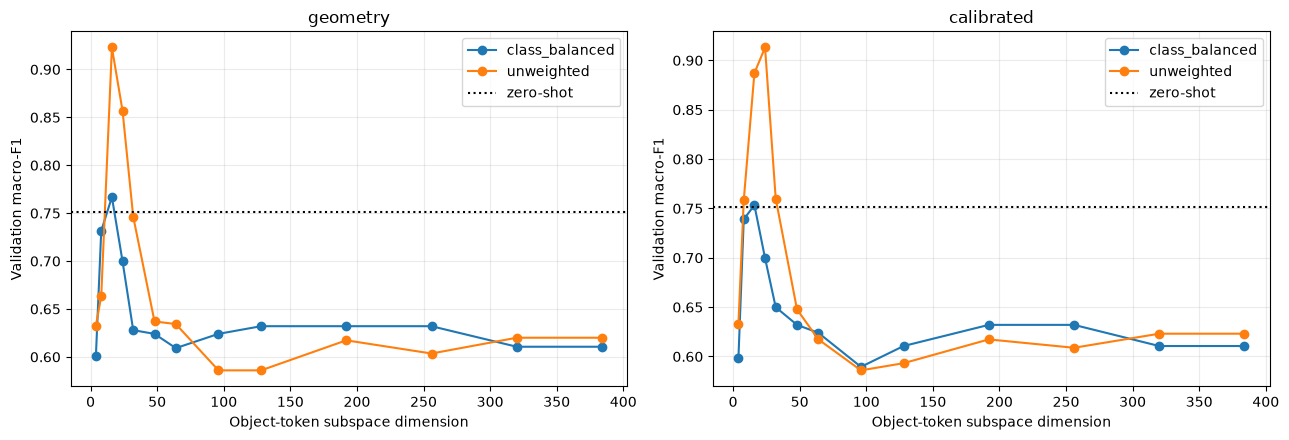

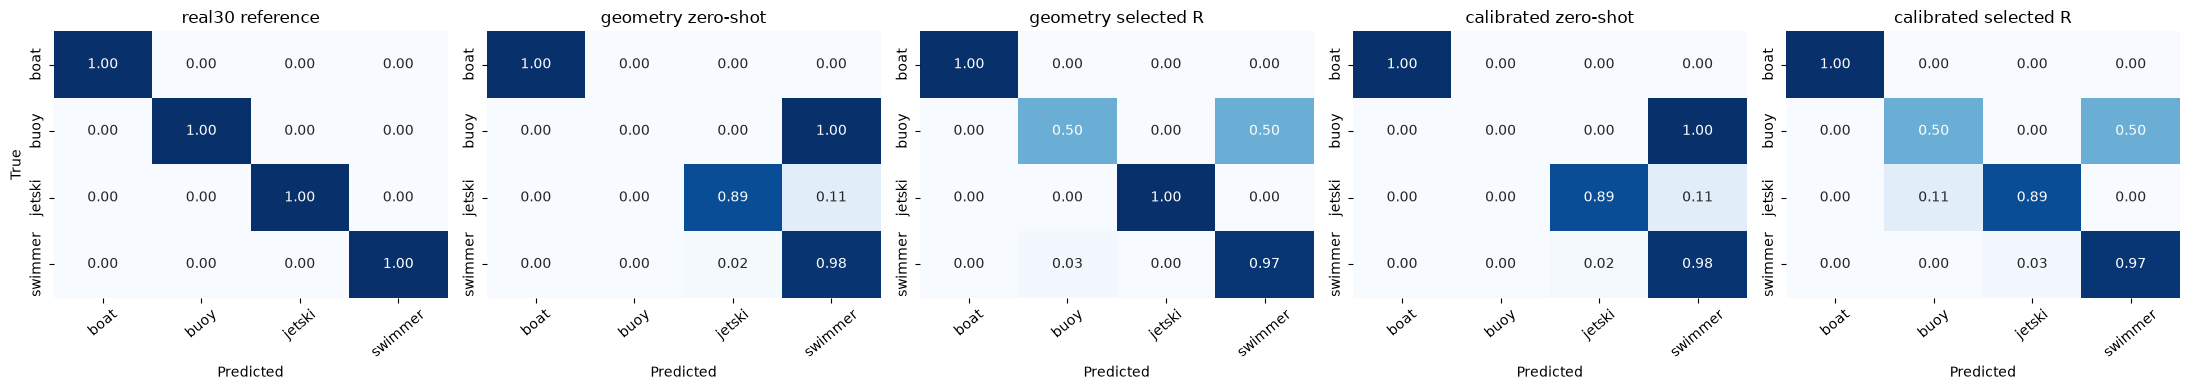

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens\attention_dimension_curves.png C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens\attention_test_confusions.png


In [10]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for variant,group in validation_results.groupby("variant"):
    for weighting,sub in group.groupby("weighting"):
        sub=sub.sort_values("dimension")
        axes[0 if variant=="geometry" else 1].plot(sub.dimension,sub.macro_f1,marker="o",label=weighting)
    raw=zero[(zero.partition=="validation")&(zero.variant==variant)].iloc[0]
    axes[0 if variant=="geometry" else 1].axhline(raw.macro_f1,color="black",linestyle=":",label="zero-shot")
    axes[0 if variant=="geometry" else 1].set_title(variant)
    axes[0 if variant=="geometry" else 1].set_xlabel("Object-token subspace dimension")
    axes[0 if variant=="geometry" else 1].set_ylabel("Validation macro-F1")
    axes[0 if variant=="geometry" else 1].grid(alpha=.25); axes[0 if variant=="geometry" else 1].legend()
plt.tight_layout(); curve=RESULT_ROOT/"attention_dimension_curves.png"; fig.savefig(curve,dpi=180,bbox_inches="tight"); plt.show()

fig,axes=plt.subplots(1,5,figsize=(22,4))
feature_arms={"real30 reference":X30_test,"geometry zero-shot":Xg_test,"geometry selected R":selected_maps["geometry"].transform(Xg_test),"calibrated zero-shot":Xc_test,"calibrated selected R":selected_maps["calibrated"].transform(Xc_test)}
for axis,(name,X) in zip(axes,feature_arms.items()):
    pred=fixed_probe.predict(X); cm=confusion_matrix(y_test,pred,labels=np.arange(len(class_names)),normalize="true")
    sns.heatmap(cm,annot=True,fmt=".2f",cmap="Blues",vmin=0,vmax=1,xticklabels=class_names,yticklabels=class_names,cbar=False,ax=axis)
    axis.set_title(name); axis.set_xlabel("Predicted"); axis.set_ylabel("True" if axis is axes[0] else ""); axis.tick_params(axis="x",rotation=40)
plt.tight_layout(); conf=RESULT_ROOT/"attention_test_confusions.png"; fig.savefig(conf,dpi=180,bbox_inches="tight"); plt.show()
print("Saved:",curve,conf)

## 8. Save the selected representation and mappings

In [11]:
map_artifacts={}
for variant,fitted in selected_maps.items():
    row=selected[selected.variant==variant].iloc[0]; prefix=f"attention_{variant}_{row.weighting}_k{int(row.dimension)}"
    np.save(RESULT_ROOT/f"{prefix}_basis.npy",fitted.basis); np.save(RESULT_ROOT/f"{prefix}_R.npy",fitted.R)
    map_artifacts[variant]={"weighting":row.weighting,"dimension":int(row.dimension),"basis":fitted.basis,"R":fitted.R,"orthogonality_error":fitted.orthogonality_error}
bundle={"model_name":MODEL_NAME,"representation":"bbox_mask_times_last4_cls_attention_patch_pool","attention_layers":LAST_ATTENTION_LAYERS,"patch_grid":[GRID_SIDE,GRID_SIDE],"mapping_direction":"synthetic_80m_to_real_30m","selected_maps":map_artifacts,"fixed_30m_probe":fixed_probe,"class_names":class_names}
joblib.dump(bundle,RESULT_ROOT/"attention_object_token_procrustes_bundle.joblib")
summary={"experiment":"attention_weighted_object_patch_token_procrustes","representation":bundle["representation"],"calibration_pairs":len(train_pairs),"validation_pairs":len(validation_pairs),"test_pairs":len(test_pairs),"zero_shot":zero.to_dict("records"),"selected":selected.to_dict("records"),"test_results":test_results.to_dict("records"),"comparison_with_global_cls":comparison.to_dict("records"),"any_selected_mapping_passed_test_gate":bool(test_results.passes_test_gate.any())}
(RESULT_ROOT/"attention_experiment_summary.json").write_text(json.dumps(summary,indent=2)+"\n",encoding="utf-8")
print("Saved bundle and summary to:",RESULT_ROOT)

Saved bundle and summary to: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens


## Observed outcome

Attention-weighted object patch tokens improved the held-out synthetic test result relative to the earlier global CLS representation.

| Representation and test variant | Zero-shot macro-F1 | Corrected macro-F1 | Selected rank | Test transfer gate |
|---|---:|---:|---:|---|
| Global CLS, geometry | 0.2879 | 0.4937 | 64 | Failed |
| Global CLS, calibrated | 0.2879 | 0.5064 | 64 | Failed |
| Object tokens, geometry | 0.6866 | **0.8017** | 16 | Passed |
| Object tokens, calibrated | 0.6866 | **0.7950** | 24 | Passed |

For the selected geometry mapping, balanced accuracy increased from 0.7178 to 0.8684, paired cosine similarity increased from 0.7694 to 0.8324, and paired RMSE decreased from 0.03465 to 0.02954. The selected mapping retained all 37 boats, corrected all 9 jet skis, and correctly classified 221 of 227 swimmers. It classified 1 of only 2 buoys correctly, so buoy performance remains too uncertain for a strong conclusion.

This result supports using the object-focused representation for the synthetic experiment. It does not establish performance on genuine 80 m data. The method also uses ground-truth bounding boxes and patch tokens whose receptive fields can still contain background context, so it suppresses background rather than removing it completely.


## Interpretation rules

- Higher macro-F1 indicates more balanced recognition across boats, buoys, jet skis, and swimmers.
- Ordinary accuracy can be misleading because swimmers dominate the test subset.
- Object-token pooling helps only if it improves over the corresponding global-CLS representation under the same split logic.
- A correction supports the geometric hypothesis only when classification and paired alignment both improve on held-out synthetic objects.
- Ground-truth boxes are supplied here. This is not yet full-image detection.
- Genuine untouched 80 m imagery remains necessary for the final external evaluation.

## 9. Strict object-disjoint unseen-test audit

The earlier test split was held out from fitting the Procrustes map, but its corresponding real 30 m objects could still appear in the object-token probe's training set. This stricter audit removes **every object that has a synthetic pair** from probe training. Consequently, every object in the final test pairs is unseen by the 30 m classifier, absent from Procrustes fitting, and absent from rank selection.

The split is:

```text
unpaired real 30 m objects -> train the fixed linear probe
synthetic train pairs      -> fit R
synthetic validation pairs -> select rank and weighting
synthetic test pairs       -> evaluate once and display examples
```


In [12]:
from sklearn.metrics import precision_recall_fscore_support
from matplotlib.patches import Rectangle

# Train the fixed 30 m classifier without any object that was used to create a
# synthetic pair. This makes every train/validation/test synthetic object unseen
# by the classifier at the object-identity level.
all_paired_object_keys = set(pairs.object_key.astype(str))
strict_probe_frame = objects[
    ~objects.object_key.astype(str).isin(all_paired_object_keys)
].copy()

assert set(strict_probe_frame.object_key.astype(str)).isdisjoint(all_paired_object_keys)
assert set(test_pairs.object_key.astype(str)).isdisjoint(
    set(strict_probe_frame.object_key.astype(str))
)
assert set(test_pairs.pair_id).isdisjoint(set(train_pairs.pair_id))
assert set(test_pairs.pair_id).isdisjoint(set(validation_pairs.pair_id))

X_strict_probe = real_matrix(strict_probe_frame)
y_strict_probe = labels_for(strict_probe_frame)
strict_probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=selected_c,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    ),
)
strict_probe.fit(X_strict_probe, y_strict_probe)

strict_split_audit = pd.DataFrame(
    {
        "role": ["30 m probe training", "R fitting", "rank selection", "final test"],
        "objects": [
            len(strict_probe_frame),
            len(train_pairs),
            len(validation_pairs),
            len(test_pairs),
        ],
        "identity_overlap_with_final_test": [0, 0, 0, len(test_pairs)],
    }
)
print("Strict probe class counts:")
display(
    strict_probe_frame.category_name.value_counts()
    .reindex(class_names, fill_value=0)
    .to_frame("probe_training_objects")
)
display(strict_split_audit)


Strict probe class counts:


,probe_training_objects
category_name,
boat,606
buoy,182
jetski,98
swimmer,956


,role,objects,identity_overlap_with_final_test
0,30 m probe training,1842,0
1,R fitting,1010,0
2,rank selection,180,0
3,final test,275,275


In [13]:
# Re-select the Procrustes rank using the strict probe and validation set.
strict_zero_rows = []
for partition, y_part, target, key in [
    ("validation", y_validation, X30_validation, "validation"),
    ("test", y_test, X30_test, "test"),
]:
    for variant, data in variant_data.items():
        strict_zero_rows.append(
            {
                "partition": partition,
                "variant": variant,
                **metrics(strict_probe, data[key], y_part, target),
            }
        )
strict_zero = pd.DataFrame(strict_zero_rows)

strict_validation_rows = []
strict_fitted_maps = {}
for variant, data in variant_data.items():
    for weighting in ["unweighted", "class_balanced"]:
        weights = None if weighting == "unweighted" else class_weights
        basis = fit_basis(data["train"], X30_train, weights)
        raw = strict_zero[
            (strict_zero.partition == "validation")
            & (strict_zero.variant == variant)
        ].iloc[0]
        for k in CANDIDATE_DIMENSIONS:
            fitted = fit_subspace(data["train"], X30_train, basis, k, weights)
            result = metrics(
                strict_probe,
                fitted.transform(data["validation"]),
                y_validation,
                X30_validation,
            )
            strict_validation_rows.append(
                {
                    "variant": variant,
                    "weighting": weighting,
                    "dimension": k,
                    "orthogonality_error": fitted.orthogonality_error,
                    **result,
                    "macro_f1_change": result["macro_f1"] - raw["macro_f1"],
                    "cosine_change": result["paired_cosine"] - raw["paired_cosine"],
                    "rmse_change": result["rmse"] - raw["rmse"],
                }
            )
            strict_fitted_maps[(variant, weighting, k)] = fitted

strict_validation = pd.DataFrame(strict_validation_rows)
strict_validation["passes_gate"] = (
    (strict_validation.macro_f1_change > 0)
    & (strict_validation.cosine_change > 0)
    & (strict_validation.rmse_change < 0)
)

strict_selected_rows = []
strict_test_rows = []
strict_selected_maps = {}
for variant in ["geometry", "calibrated"]:
    candidates = strict_validation[strict_validation.variant == variant]
    passing = candidates[candidates.passes_gate]
    pool = passing if len(passing) else candidates
    chosen = pool.sort_values(
        ["macro_f1", "paired_cosine"], ascending=False
    ).iloc[0]
    fitted = strict_fitted_maps[
        (variant, str(chosen.weighting), int(chosen.dimension))
    ]
    result = metrics(
        strict_probe,
        fitted.transform(variant_data[variant]["test"]),
        y_test,
        X30_test,
    )
    raw = strict_zero[
        (strict_zero.partition == "test") & (strict_zero.variant == variant)
    ].iloc[0]
    strict_selected_rows.append(
        {
            "variant": variant,
            "weighting": chosen.weighting,
            "dimension": int(chosen.dimension),
            "validation_gate": bool(chosen.passes_gate),
            "validation_macro_f1": chosen.macro_f1,
        }
    )
    strict_test_rows.append(
        {
            "variant": variant,
            "weighting": chosen.weighting,
            "dimension": int(chosen.dimension),
            **result,
            "macro_f1_change": result["macro_f1"] - raw["macro_f1"],
            "cosine_change": result["paired_cosine"] - raw["paired_cosine"],
            "rmse_change": result["rmse"] - raw["rmse"],
            "passes_test_gate": bool(
                result["macro_f1"] > raw["macro_f1"]
                and result["paired_cosine"] > raw["paired_cosine"]
                and result["rmse"] < raw["rmse"]
            ),
        }
    )
    strict_selected_maps[variant] = fitted

strict_selected = pd.DataFrame(strict_selected_rows)
strict_test_results = pd.DataFrame(strict_test_rows)
strict_validation.to_csv(
    RESULT_ROOT / "strict_unseen_validation_results.csv", index=False
)
strict_selected.to_csv(
    RESULT_ROOT / "strict_unseen_selected_models.csv", index=False
)
strict_test_results.to_csv(
    RESULT_ROOT / "strict_unseen_test_results.csv", index=False
)

print("Strict object-disjoint zero-shot test:")
display(strict_zero[strict_zero.partition == "test"])
print("Selected only from validation:")
display(strict_selected)
print("Strict object-disjoint final test:")
display(strict_test_results)


Strict object-disjoint zero-shot test:


,partition,variant,accuracy,balanced_accuracy,macro_f1,rmse,paired_cosine
2,test,geometry,0.981818,0.693343,0.703147,0.034654,0.769422
3,test,calibrated,0.981818,0.693343,0.703147,0.034596,0.770200


Selected only from validation:


,variant,weighting,dimension,validation_gate,validation_macro_f1
0,geometry,unweighted,24,True,0.87985
1,calibrated,unweighted,24,True,0.87985


Strict object-disjoint final test:


,variant,weighting,dimension,accuracy,balanced_accuracy,macro_f1,rmse,paired_cosine,macro_f1_change,cosine_change,rmse_change,passes_test_gate
0,geometry,unweighted,24,0.970909,0.840614,0.786032,0.029683,0.830838,0.082885,0.061416,-0.004972,True
1,calibrated,unweighted,24,0.970909,0.840614,0.769912,0.029657,0.831133,0.066765,0.060933,-0.004939,True


### Confusion matrices and per-class results

The 30 m reference matrix checks whether the new strict probe can recognize the unseen real 30 m source objects. The other matrices apply that same unchanged classifier to synthetic 80 m features before and after the selected correction.


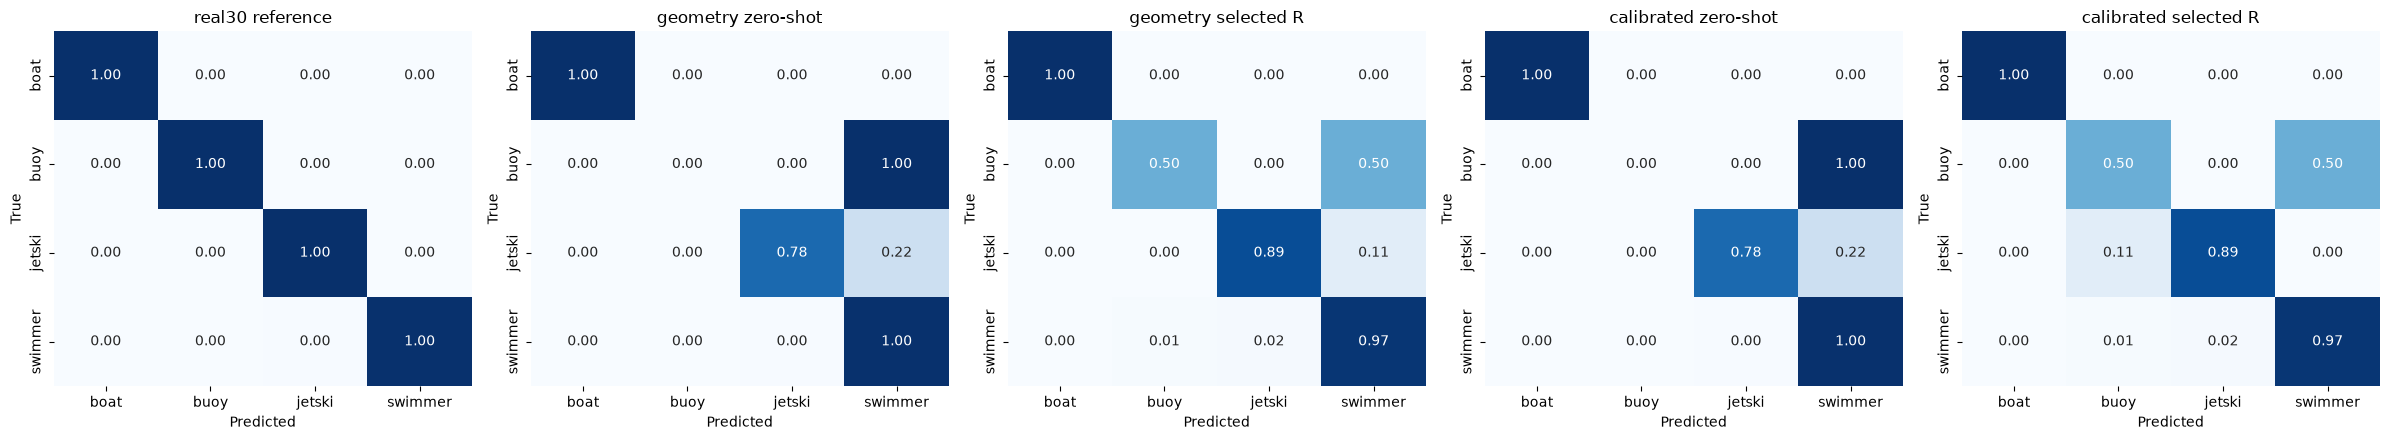

f1  precision  recall  support
evaluation            class                                      
calibrated selected R boat     1.0000     1.0000  1.0000     37.0
                      buoy     0.3333     0.2500  0.5000      2.0
                      jetski   0.7619     0.6667  0.8889      9.0
                      swimmer  0.9844     0.9955  0.9736    227.0
calibrated zero-shot  boat     1.0000     1.0000  1.0000     37.0
                      buoy     0.0000     0.0000  0.0000      2.0
                      jetski   0.8235     0.8750  0.7778      9.0
                      swimmer  0.9891     0.9826  0.9956    227.0
geometry selected R   boat     1.0000     1.0000  1.0000     37.0
                      buoy     0.4000     0.3333  0.5000      2.0
                      jetski   0.7619     0.6667  0.8889      9.0
                      swimmer  0.9822     0.9910  0.9736    227.0
geometry zero-shot    boat     1.0000     1.0000  1.0000     37.0
                      buoy     0.0000     0.0000  0.0000      2.0
                      jetski   0.8235     0.8750  0.7778      9.0
                      swimmer  0.9891     0.9826  0.9956    227.0
real30 reference      boat     1.0000     1.0000  1.0000     37.0
                      buoy     1.0000     1.0000  1.0000      2.0
                      jetski   0.9474     0.9000  1.0000      9.0
                      swimmer  0.9978     1.0000  0.9956    227.0

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens\strict_unseen_test_confusions.png


In [14]:
strict_predictions = {
    "real30 reference": strict_probe.predict(X30_test),
    "geometry zero-shot": strict_probe.predict(Xg_test),
    "geometry selected R": strict_probe.predict(
        strict_selected_maps["geometry"].transform(Xg_test)
    ),
    "calibrated zero-shot": strict_probe.predict(Xc_test),
    "calibrated selected R": strict_probe.predict(
        strict_selected_maps["calibrated"].transform(Xc_test)
    ),
}

figure, axes = plt.subplots(1, len(strict_predictions), figsize=(24, 4.5))
per_class_rows = []
for axis, (name, prediction) in zip(axes, strict_predictions.items()):
    matrix = confusion_matrix(
        y_test, prediction, labels=np.arange(len(class_names)), normalize="true"
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        ax=axis,
    )
    axis.set_title(name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        prediction,
        labels=np.arange(len(class_names)),
        zero_division=0,
    )
    for index, class_name in enumerate(class_names):
        per_class_rows.append(
            {
                "evaluation": name,
                "class": class_name,
                "precision": precision[index],
                "recall": recall[index],
                "f1": f1[index],
                "support": int(support[index]),
            }
        )

figure.tight_layout()
strict_confusion_path = RESULT_ROOT / "strict_unseen_test_confusions.png"
figure.savefig(strict_confusion_path, dpi=180, bbox_inches="tight")
plt.show()

strict_per_class = pd.DataFrame(per_class_rows)
strict_per_class.to_csv(
    RESULT_ROOT / "strict_unseen_per_class_metrics.csv", index=False
)
display(
    strict_per_class.pivot_table(
        index=["evaluation", "class"],
        values=["precision", "recall", "f1", "support"],
    ).round(4)
)
print("Saved:", strict_confusion_path)


### Show unseen 30 m → synthetic 80 m pairs

One test object from each class is shown. The red box indicates the object region used to construct the attention-weighted token. Predictions are made by the strict 30 m classifier. `zero` is the direct synthetic prediction; `R` is the prediction after the validation-selected Procrustes correction.


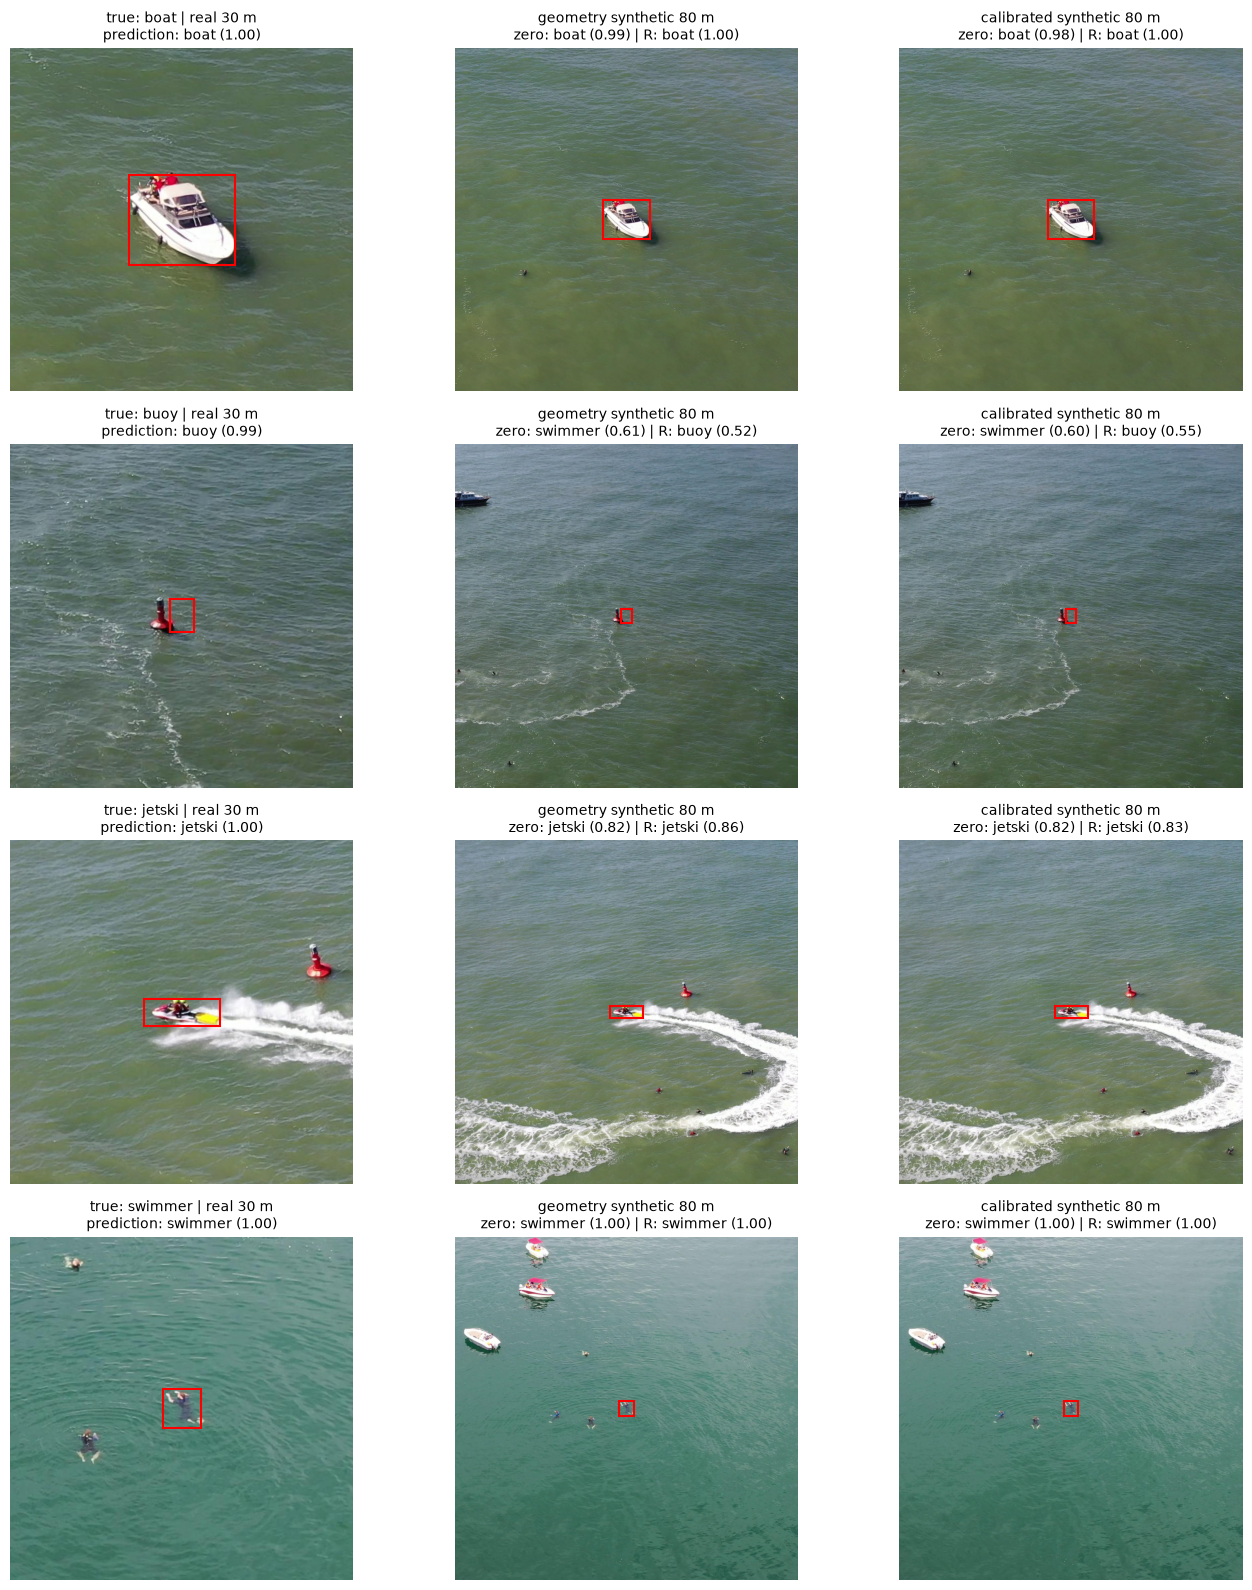

Every displayed object is absent from strict probe training: True
Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens\strict_unseen_test_examples.png


In [15]:
# Choose one deterministic unseen test object per class.
example_rows = (
    test_pairs.groupby("category_name", group_keys=False)
    .sample(n=1, random_state=SEED)
    .sort_values("category_name")
)
test_position = {pair_id: i for i, pair_id in enumerate(test_pairs.pair_id)}

real_probabilities = strict_probe.predict_proba(X30_test)
geometry_zero_probabilities = strict_probe.predict_proba(Xg_test)
geometry_R_probabilities = strict_probe.predict_proba(
    strict_selected_maps["geometry"].transform(Xg_test)
)
calibrated_zero_probabilities = strict_probe.predict_proba(Xc_test)
calibrated_R_probabilities = strict_probe.predict_proba(
    strict_selected_maps["calibrated"].transform(Xc_test)
)


def prediction_text(probabilities, position):
    predicted = int(np.argmax(probabilities[position]))
    return f"{class_names[predicted]} ({probabilities[position, predicted]:.2f})"


def draw_box(axis, bbox):
    x, y, width, height = map(float, bbox)
    axis.add_patch(
        Rectangle(
            (x, y), width, height, fill=False, edgecolor="red", linewidth=1.5
        )
    )


figure, axes = plt.subplots(len(example_rows), 3, figsize=(14, 4 * len(example_rows)))
for row_number, (_, row) in enumerate(example_rows.iterrows()):
    position = test_position[row.pair_id]
    object_row = objects.loc[objects.object_key == row.object_key].iloc[0]

    with Image.open(REPO_ROOT / Path(str(object_row.image_path))) as opened:
        real_image, real_bbox = fixed_canvas_crop_with_bbox(
            opened.convert("RGB"),
            (
                object_row.bbox_x,
                object_row.bbox_y,
                object_row.bbox_width,
                object_row.bbox_height,
            ),
        )
    with Image.open(REPO_ROOT / Path(str(row.geometry_image_path))) as opened:
        geometry_image = opened.convert("RGB")
    with Image.open(REPO_ROOT / Path(str(row.calibrated_image_path))) as opened:
        calibrated_image = opened.convert("RGB")

    synthetic_bbox = (
        row.synthetic_bbox_x,
        row.synthetic_bbox_y,
        row.synthetic_bbox_width,
        row.synthetic_bbox_height,
    )
    panels = [real_image, geometry_image, calibrated_image]
    boxes = [real_bbox, synthetic_bbox, synthetic_bbox]
    titles = [
        (
            f"true: {row.category_name} | real 30 m\n"
            f"prediction: {prediction_text(real_probabilities, position)}"
        ),
        (
            "geometry synthetic 80 m\n"
            f"zero: {prediction_text(geometry_zero_probabilities, position)} | "
            f"R: {prediction_text(geometry_R_probabilities, position)}"
        ),
        (
            "calibrated synthetic 80 m\n"
            f"zero: {prediction_text(calibrated_zero_probabilities, position)} | "
            f"R: {prediction_text(calibrated_R_probabilities, position)}"
        ),
    ]
    for column, (image, bbox, title) in enumerate(zip(panels, boxes, titles)):
        axes[row_number, column].imshow(image)
        draw_box(axes[row_number, column], bbox)
        axes[row_number, column].set_title(title, fontsize=10)
        axes[row_number, column].axis("off")

figure.tight_layout()
strict_examples_path = RESULT_ROOT / "strict_unseen_test_examples.png"
figure.savefig(strict_examples_path, dpi=180, bbox_inches="tight")
plt.show()
print("Every displayed object is absent from strict probe training:", True)
print("Saved:", strict_examples_path)


In [16]:
# Save a compact machine-readable record of this strict audit.
strict_summary = {
    "experiment": "strict_object_disjoint_attention_token_procrustes",
    "probe_training_objects": len(strict_probe_frame),
    "mapping_train_pairs": len(train_pairs),
    "validation_pairs": len(validation_pairs),
    "test_pairs": len(test_pairs),
    "test_class_counts": {
        name: int((test_pairs.category_name == name).sum()) for name in class_names
    },
    "zero_shot": strict_zero.to_dict("records"),
    "selected": strict_selected.to_dict("records"),
    "test_results": strict_test_results.to_dict("records"),
}
(RESULT_ROOT / "strict_unseen_summary.json").write_text(
    json.dumps(strict_summary, indent=2) + "\n", encoding="utf-8"
)
joblib.dump(
    {
        "representation": "bbox_mask_times_last4_cls_attention_patch_pool",
        "mapping_direction": "synthetic_80m_to_real_30m",
        "fixed_30m_probe": strict_probe,
        "selected_maps": strict_selected_maps,
        "class_names": class_names,
    },
    RESULT_ROOT / "strict_unseen_attention_procrustes_bundle.joblib",
)
print("Strict unseen audit artifacts saved to:", RESULT_ROOT)


Strict unseen audit artifacts saved to: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens


## Strict unseen-test outcome

The strict 30 m probe was trained on 1,842 real objects that have no synthetic counterpart. The 1,010 mapping pairs, 180 validation pairs, and 275 final test pairs are object-disjoint from probe training.

| Synthetic variant | Zero-shot macro-F1 | Corrected macro-F1 | Corrected balanced accuracy | Selected rank | Test gate |
|---|---:|---:|---:|---:|---|
| Geometry only | 0.7031 | **0.7860** | 0.8406 | 24 | Passed |
| Calibrated | 0.7031 | **0.7699** | 0.8406 | 24 | Passed |

The geometry mapping improved paired cosine similarity from 0.7694 to 0.8308 and reduced paired RMSE from 0.03465 to 0.02968. On the imbalanced test set it achieved recall of 1.00 for boats (37 objects), 0.50 for buoys (2 objects), 0.89 for jet skis (9 objects), and 0.97 for swimmers (227 objects). The buoy estimate is especially uncertain because it is based on only two test examples.

This object-disjoint audit is the appropriate synthetic result to report. It still requires evaluation on untouched genuine 80 m data before supporting a real-altitude conclusion.


## 10. Genuine held-out 80 m boat sanity check

This section applies the synthetic-trained correction to annotated boats in genuine SeaDronesSee images captured at 75–85 m. The reserved videos `DJI_0064.MP4` and `DJI_0065.MP4` were not opened during simulator calibration and do not occur in the 30 m training manifest.

No real 30 m image is paired with these 80 m boats. Such a pair is unnecessary for inference:

```text
unseen genuine 80 m boat crop
        ↓ frozen DINOv2
attention-weighted object feature
        ↓ synthetic-trained R
corrected 30 m-style feature
        ↓ fixed strict 30 m classifier
prediction
```

Because corresponding 30 m observations do not exist, this section can measure classification behavior but cannot calculate paired feature RMSE, paired cosine similarity, or prove that the corrected feature equals the object's true 30 m feature.


In [17]:
# Load only the previously reserved genuine-80 m videos.
REAL80_MIN_M = 75.0
REAL80_MAX_M = 85.0
HELDOUT_REAL80_VIDEOS = {"DJI_0064.MP4", "DJI_0065.MP4"}
ODV2_ROOT = REPO_ROOT / "data/raw/seadronessee/odv2"

assert set(objects.video.astype(str)).isdisjoint(HELDOUT_REAL80_VIDEOS)

real80_boat_rows = []
for source_split in ["train", "val"]:
    annotation_path = ODV2_ROOT / "annotations" / f"instances_{source_split}.json"
    coco = json.loads(annotation_path.read_text(encoding="utf-8"))
    category_names = {item["id"]: item["name"] for item in coco["categories"]}
    image_lookup = {item["id"]: item for item in coco["images"]}
    for annotation in coco["annotations"]:
        if category_names.get(annotation["category_id"]) != "boat":
            continue
        image_record = image_lookup[annotation["image_id"]]
        source = image_record.get("source") or {}
        metadata = image_record.get("meta") or {}
        video = source.get("video")
        altitude = metadata.get("height_above_takeoff(meter)")
        if video not in HELDOUT_REAL80_VIDEOS or altitude is None:
            continue
        if not REAL80_MIN_M <= float(altitude) <= REAL80_MAX_M:
            continue
        x, y, width, height = annotation["bbox"]
        image_path = ODV2_ROOT / "images" / source_split / image_record["file_name"]
        real80_boat_rows.append(
            {
                "object_key": f"real80:{source_split}:{annotation['id']}",
                "annotation_id": int(annotation["id"]),
                "image_key": f"{source_split}:{image_record['id']}",
                "source_split": source_split,
                "image_path": str(image_path.relative_to(REPO_ROOT)),
                "video": video,
                "frame_no": int(source.get("frame_no", image_record["id"])),
                "altitude_m": float(altitude),
                "bbox_x": float(x),
                "bbox_y": float(y),
                "bbox_width": float(width),
                "bbox_height": float(height),
                "category_name": "boat",
            }
        )

real80_boats = (
    pd.DataFrame(real80_boat_rows)
    .sort_values(["video", "frame_no", "annotation_id"])
    .reset_index(drop=True)
)
if real80_boats.empty:
    raise RuntimeError("No held-out boat annotations were found at 75–85 m.")

real80_audit = pd.DataFrame(
    {
        "objects": [len(real80_boats)],
        "unique_frames": [real80_boats.image_key.nunique()],
        "videos_with_boats": [real80_boats.video.nunique()],
        "minimum_altitude_m": [real80_boats.altitude_m.min()],
        "maximum_altitude_m": [real80_boats.altitude_m.max()],
        "overlap_with_30m_manifest_videos": [
            len(set(real80_boats.video) & set(objects.video.astype(str)))
        ],
    }
)
display(real80_audit)
display(
    real80_boats.groupby(["video", "image_key", "frame_no", "altitude_m"])
    .size()
    .rename("boat_annotations")
    .reset_index()
)


,objects,unique_frames,videos_with_boats,minimum_altitude_m,maximum_altitude_m,overlap_with_30m_manifest_videos
0,12,4,1,77.596216,81.996001,0


,video,image_key,frame_no,altitude_m,boat_annotations
0,DJI_0065.MP4,train:5285,2265,77.596216,3
1,DJI_0065.MP4,train:5286,2280,77.596216,3
2,DJI_0065.MP4,train:5287,2295,81.996001,3
3,DJI_0065.MP4,train:5288,2310,81.996001,3


In [18]:
# Extract the same attention-weighted object representation used above.
X_real80_boats = extract_attention_object_features(
    real80_boats,
    kind="real30",  # Uses the fixed 640 px real-image crop path; altitude is irrelevant here.
    cache_name="real80_heldout_boats",
)

real80_feature_sets = {
    "zero_shot": X_real80_boats,
    "geometry_R": strict_selected_maps["geometry"].transform(X_real80_boats),
    "calibrated_R": strict_selected_maps["calibrated"].transform(X_real80_boats),
}

real80_prediction_rows = []
real80_probabilities = {}
for method, features in real80_feature_sets.items():
    probabilities = strict_probe.predict_proba(features)
    real80_probabilities[method] = probabilities
    predictions = np.argmax(probabilities, axis=1)
    for index, row in real80_boats.iterrows():
        predicted_index = int(predictions[index])
        real80_prediction_rows.append(
            {
                **row.to_dict(),
                "method": method,
                "predicted_class": class_names[predicted_index],
                "prediction_confidence": float(probabilities[index, predicted_index]),
                "boat_probability": float(probabilities[index, label_to_index["boat"]]),
                "correct": bool(class_names[predicted_index] == "boat"),
            }
        )

real80_predictions = pd.DataFrame(real80_prediction_rows)
real80_summary = (
    real80_predictions.groupby("method", sort=False)
    .agg(
        annotated_boats=("annotation_id", "size"),
        unique_frames=("image_key", "nunique"),
        predicted_boat=("correct", "sum"),
        boat_recall=("correct", "mean"),
        mean_boat_probability=("boat_probability", "mean"),
        median_boat_probability=("boat_probability", "median"),
    )
    .reset_index()
)
real80_predictions.to_csv(
    RESULT_ROOT / "real80_heldout_boat_predictions.csv", index=False
)
real80_summary.to_csv(
    RESULT_ROOT / "real80_heldout_boat_summary.csv", index=False
)
display(real80_summary.style.format({
    "boat_recall": "{:.3f}",
    "mean_boat_probability": "{:.3f}",
    "median_boat_probability": "{:.3f}",
}))


real80_heldout_boats:   0%|          | 0/1 [00:00<?, ?it/s]

real80_heldout_boats: 100%|██████████| 1/1 [00:01<00:00,  1.36s/it]

real80_heldout_boats: 100%|██████████| 1/1 [00:01<00:00,  1.36s/it]

Saved cache: real80_heldout_boats.npz (12, 384)


,method,annotated_boats,unique_frames,predicted_boat,boat_recall,mean_boat_probability,median_boat_probability
0,zero_shot,12,4,12,1.000,0.976,0.979
1,geometry_R,12,4,12,1.000,0.991,0.991
2,calibrated_R,12,4,12,1.000,0.991,0.992


### Prediction distribution

Only boats are present in this small external check, so a full four-class confusion matrix cannot be estimated. The following one-row matrices show which class each annotated boat was assigned to. Boat recall is the boat-to-boat cell.


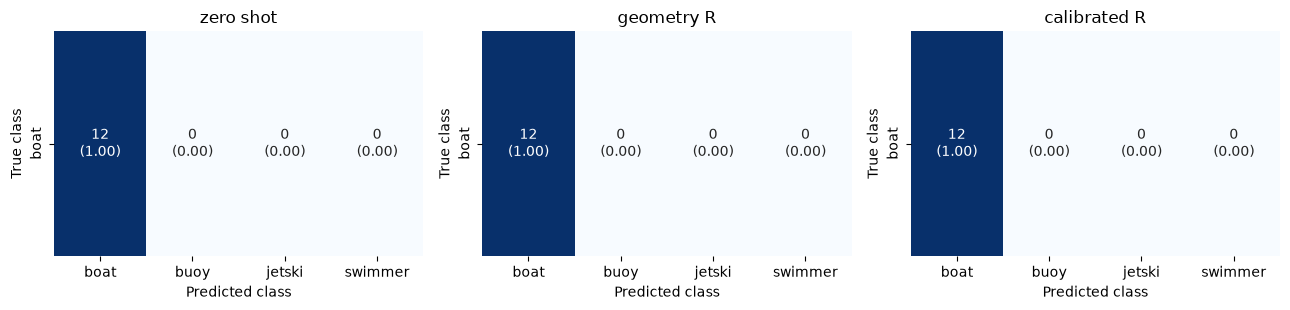

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens\real80_heldout_boat_prediction_distribution.png


In [19]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for axis, method in zip(axes, ["zero_shot", "geometry_R", "calibrated_R"]):
    predictions = real80_predictions[real80_predictions.method == method]
    counts = (
        predictions.predicted_class.value_counts()
        .reindex(class_names, fill_value=0)
        .to_numpy(dtype=float)
    )
    proportions = counts / counts.sum()
    sns.heatmap(
        proportions.reshape(1, -1),
        annot=np.array([[f"{int(count)}\n({proportion:.2f})" for count, proportion in zip(counts, proportions)]]),
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=["boat"],
        cbar=False,
        ax=axis,
    )
    axis.set_title(method.replace("_", " "))
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
figure.tight_layout()
real80_distribution_path = RESULT_ROOT / "real80_heldout_boat_prediction_distribution.png"
figure.savefig(real80_distribution_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", real80_distribution_path)


### Representative genuine 80 m boats

One annotation is displayed from each of the four available frames. These are not four independent flight scenes: all come from one reserved video, and neighbouring frames may contain the same physical boats. The full numerical summary therefore reports annotation-level behavior and the number of unique frames.


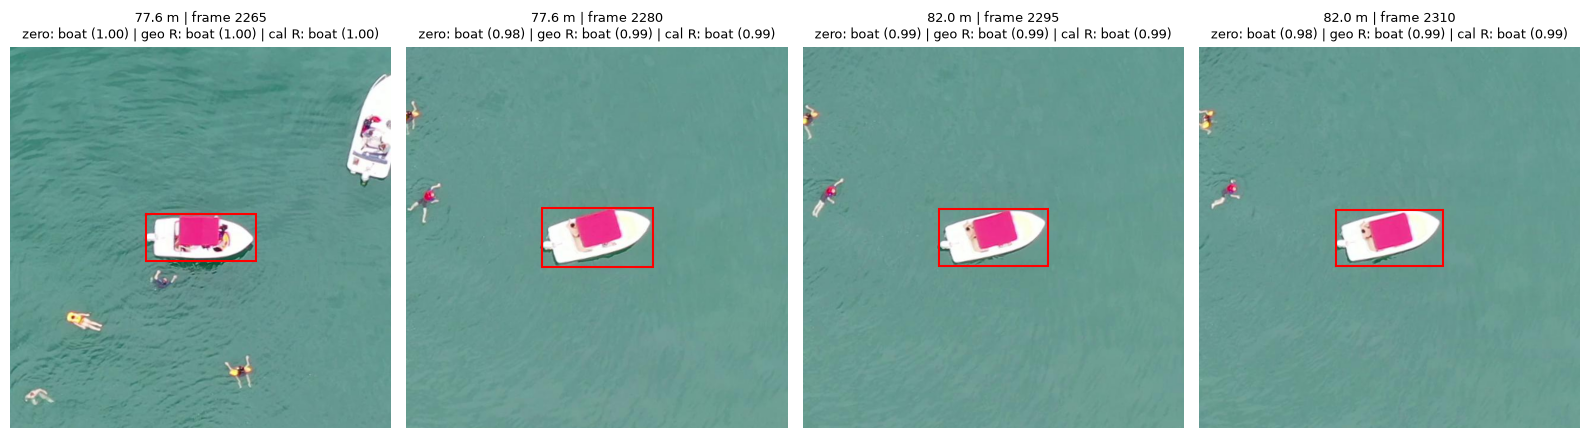

Saved: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_attention_object_tokens\real80_heldout_boat_examples.png


In [20]:
# Select one boat annotation per available frame for visualization.
real80_examples = (
    real80_boats.sort_values(["image_key", "bbox_width"], ascending=[True, False])
    .drop_duplicates("image_key")
    .reset_index(drop=True)
)

figure, axes = plt.subplots(1, len(real80_examples), figsize=(4 * len(real80_examples), 4.5))
if len(real80_examples) == 1:
    axes = [axes]

object_position = {key: index for index, key in enumerate(real80_boats.object_key)}
for axis, (_, row) in zip(axes, real80_examples.iterrows()):
    position = object_position[row.object_key]
    with Image.open(REPO_ROOT / Path(str(row.image_path))) as opened:
        crop, crop_bbox = fixed_canvas_crop_with_bbox(
            opened.convert("RGB"),
            (row.bbox_x, row.bbox_y, row.bbox_width, row.bbox_height),
        )
    axis.imshow(crop)
    draw_box(axis, crop_bbox)

    lines = []
    for method, short_name in [
        ("zero_shot", "zero"),
        ("geometry_R", "geo R"),
        ("calibrated_R", "cal R"),
    ]:
        probabilities = real80_probabilities[method][position]
        predicted_index = int(np.argmax(probabilities))
        lines.append(
            f"{short_name}: {class_names[predicted_index]} "
            f"({probabilities[predicted_index]:.2f})"
        )
    axis.set_title(
        f"{row.altitude_m:.1f} m | frame {row.frame_no}\n" + " | ".join(lines),
        fontsize=9,
    )
    axis.axis("off")

figure.tight_layout()
real80_examples_path = RESULT_ROOT / "real80_heldout_boat_examples.png"
figure.savefig(real80_examples_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", real80_examples_path)


In [21]:
real80_boat_record = {
    "experiment": "unmatched_genuine_80m_boat_sanity_check",
    "altitude_range_m": [REAL80_MIN_M, REAL80_MAX_M],
    "reserved_videos": sorted(HELDOUT_REAL80_VIDEOS),
    "videos_containing_eligible_boats": sorted(real80_boats.video.unique()),
    "annotations": len(real80_boats),
    "unique_frames": int(real80_boats.image_key.nunique()),
    "ground_truth_boxes_used": True,
    "paired_30m_observations_available": False,
    "summary": real80_summary.to_dict("records"),
    "interpretation": (
        "Classification-only external sanity check. Repeated annotations from four "
        "frames in one video are not independent and cannot establish general real-80 m performance."
    ),
}
(RESULT_ROOT / "real80_heldout_boat_summary.json").write_text(
    json.dumps(real80_boat_record, indent=2) + "\n", encoding="utf-8"
)
print(json.dumps(real80_boat_record, indent=2))


{
  "experiment": "unmatched_genuine_80m_boat_sanity_check",
  "altitude_range_m": [
    75.0,
    85.0
  ],
  "reserved_videos": [
    "DJI_0064.MP4",
    "DJI_0065.MP4"
  ],
  "videos_containing_eligible_boats": [
    "DJI_0065.MP4"
  ],
  "annotations": 12,
  "unique_frames": 4,
  "ground_truth_boxes_used": true,
  "paired_30m_observations_available": false,
  "summary": [
    {
      "method": "zero_shot",
      "annotated_boats": 12,
      "unique_frames": 4,
      "predicted_boat": 12,
      "boat_recall": 1.0,
      "mean_boat_probability": 0.9758625676234564,
      "median_boat_probability": 0.9790941178798676
    },
    {
      "method": "geometry_R",
      "annotated_boats": 12,
      "unique_frames": 4,
      "predicted_boat": 12,
      "boat_recall": 1.0,
      "mean_boat_probability": 0.9910238536515771,
      "median_boat_probability": 0.9914500446025519
    },
    {
      "method": "calibrated_R",
      "annotated_boats": 12,
      "unique_frames": 4,
      "predicted_bo

## Genuine 80 m boat outcome

All 12 annotated boats were classified as boats by the strict 30 m classifier before correction and after both synthetic-trained corrections. Mean boat probability increased from 0.9759 zero-shot to 0.9910 with the geometry mapping and 0.9912 with the calibrated mapping.

This is evidence that the 30 m object classifier transfers to these genuine 77.6–82.0 m boat crops. It is not evidence that the Procrustes correction improved classification, because zero-shot boat recall was already 1.0 and no predictions changed. The increase in confidence alone should not be interpreted as improved accuracy without a larger multi-class set and probability-calibration analysis.

The 12 annotations come from only four neighbouring frames in one video and likely repeat the same three physical boats. Ground-truth boxes are supplied, no matched 30 m observations exist, and no non-boat examples are included. This remains a small external sanity check rather than the final genuine-80 m evaluation.
